# 06 G-Gene Haplotype Reconstruction

**Methods mapping:** G-gene haplotype reconstruction.

This notebook parses the G-gene haplotype FASTA files, uses the linked-site set from the LoFreq screen, and extracts the corresponding bases from each haplotype sequence in the validation samples.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('06_g_gene_haplotype_reconstruction', ROOT)
INPUTS = {
    "lofreq_raw_calls": ROOT / "data/input/isnv/lofreq_raw_calls.csv",
    "metadata": ROOT / "data/metadata/meta_v6_with_season_clade.csv",
    "AU_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1037681_extracted_4652-5617.fasta",
    "US_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1130896_extracted_4652-5617.fasta",
}
OUTPUTS = {
    "haplotype_site_combos": DATA_DIR / "haplotype_site_combos_per_haplotype.csv",
    "combo_frequency_matrix": DATA_DIR / "haplotype_combo_frequency_matrix.csv",
    "haplotype_count_distribution": DATA_DIR / "haplotype_count_distribution.csv",
    "haplotype_site_state_matrix": DATA_DIR / "haplotype_site_state_matrix.csv",
    "figure_png": FIG_DIR / "Fig2BCD_haplotype_reconstruction.png",
    "figure_pdf": FIG_DIR / "Fig2BCD_haplotype_reconstruction.pdf",
    "figure_svg": FIG_DIR / "Fig2BCD_haplotype_reconstruction.svg",
}


def show_paths(title, paths):
    rows = []
    for name, path in paths.items():
        path = Path(path)
        rows.append({"name": name, "relative_path": rel(path), "exists": path.exists()})
    display(Markdown(f"### {title}"))
    display(pd.DataFrame(rows))

for path in OUTPUTS.values():
    Path(path).parent.mkdir(parents=True, exist_ok=True)

show_paths("Input paths", INPUTS)
show_paths("Output paths", OUTPUTS)
DATA_DIR, FIG_DIR


### Input paths

,name,relative_path,exists
0,lofreq_raw_calls,data/input/isnv/lofreq_raw_calls.csv,True
1,metadata,data/metadata/meta_v6_with_season_clade.csv,True
2,AU_haplotype_fasta,data/input/haplotypes/PRJNA1037681_...,True
3,US_haplotype_fasta,data/input/haplotypes/PRJNA1130896_...,True


### Output paths

,name,relative_path,exists
0,haplotype_site_combos,data/processed_data/06_g_gene_haplotype_...,True
1,combo_frequency_matrix,data/processed_data/06_g_gene_haplotype_...,True
2,haplotype_count_distribution,data/processed_data/06_g_gene_haplotype_...,True
3,haplotype_site_state_matrix,data/processed_data/06_g_gene_haplotype_...,True
4,figure_png,results/figures/06_g_gene_haplotype...,True
5,figure_pdf,results/figures/06_g_gene_haplotype...,True
6,figure_svg,results/figures/06_g_gene_haplotype...,True


(PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/data/processed_data/06_g_gene_haplotype_reconstruction'),
 PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/results/figures/06_g_gene_haplotype_reconstruction'))

## Read Haplotype FASTA and Linked Sites

Haplotype identities, frequencies, and sample IDs are parsed from FASTA headers. The site set comes from the LoFreq recurrence screen in step 05.


In [3]:
hap_records = au.load_haplotype_records(ROOT)
selected_samples = au.selected_linked_validation_samples(ROOT)
site_sets = au.derive_linked_site_sets(ROOT)
site_table = pd.DataFrame([
    {'project': project, 'position': site['position'], 'ref': site['ref'], 'alt': site['alt']}
    for project, sites in site_sets.items()
    for site in sites
])

display(hap_records.groupby('project', as_index=False).agg(haplotypes=('SequenceName', 'count'), samples=('SampleID', 'nunique')))
display(site_table)
display(selected_samples[['project', 'SampleID', 'selected_TreeCluster_combo', 'global_short_label']].head())


,project,haplotypes,samples
0,PRJNA1037681,74,37
1,PRJNA1130896,144,72


,project,position,ref,alt
0,PRJNA1037681,5510,G,A
1,PRJNA1037681,5520,A,T
2,PRJNA1037681,5544,C,T
3,PRJNA1037681,5558,G,A
4,PRJNA1037681,5563,T,C
5,PRJNA1130896,5531,T,C
6,PRJNA1130896,5561,T,C


,project,SampleID,selected_TreeCluster_combo,global_short_label
0,PRJNA1037681,SRR26779971,C4+C6,AU-S01
1,PRJNA1037681,SRR26780187,C4+C6,AU-S02
2,PRJNA1037681,SRR26780146,C4+C6,AU-S03
3,PRJNA1037681,SRR26780067,C4+C6,AU-S04
4,PRJNA1037681,SRR26780216,C4+C6,AU-S05


## Rebuild Haplotype Site-Combination Tables

The generated table records the linked-site state for each haplotype sequence, then collapses haplotype frequencies by sample and site combination.


In [4]:
hap, combo_matrix, count_values = au.haplotype_reconstruction(ROOT, DATA_DIR)

display(hap.head())
display(combo_matrix.head())
display(count_values)


,project,SampleID,SequenceName,haplotype_id,haplotype_frequency,site_positions,site_combo,global_short_label,collection_date,selected_TreeCluster_combo,collection_dt
0,PRJNA1037681,SRR26779971,PRJNA1037681_SRR26779971_H1_freq0.724469925402...,H1,0.724470,5510;5520;5544;5558;5563,G-A-T-A-T,AU-S01,2022/5/15,C4+C6,2022-05-15
1,PRJNA1037681,SRR26779971,PRJNA1037681_SRR26779971_H2_freq0.275530074597...,H2,0.275530,5510;5520;5544;5558;5563,A-T-C-G-C,AU-S01,2022/5/15,C4+C6,2022-05-15
2,PRJNA1037681,SRR26779974,PRJNA1037681_SRR26779974_H1_freq0.714021896184...,H1,0.714022,5510;5520;5544;5558;5563,G-A-T-A-T,AU-S16,2022/7/10,C4+C6,2022-07-10
3,PRJNA1037681,SRR26779974,PRJNA1037681_SRR26779974_H2_freq0.285978103815...,H2,0.285978,5510;5520;5544;5558;5563,A-T-C-G-C,AU-S16,2022/7/10,C4+C6,2022-07-10
4,PRJNA1037681,SRR26779980,PRJNA1037681_SRR26779980_H1_freq0.808170248209...,H1,0.808170,5510;5520;5544;5558;5563,G-A-T-A-T,AU-S12,2022/6/25,C4+C6,2022-06-25


site_combo,project,SampleID,global_short_label,A-T-C-G-C,C-C,G-A-C-G-C,G-A-T-A-T,T-T
0,PRJNA1037681,SRR26779971,AU-S01,0.275530,0.0,0.0,0.724470,0.0
1,PRJNA1037681,SRR26779974,AU-S16,0.285978,0.0,0.0,0.714022,0.0
2,PRJNA1037681,SRR26779980,AU-S12,0.191830,0.0,0.0,0.808170,0.0
3,PRJNA1037681,SRR26779981,AU-S17,0.271003,0.0,0.0,0.728997,0.0
4,PRJNA1037681,SRR26779985,AU-S18,0.257804,0.0,0.0,0.742196,0.0


,project,haplotype_count_class,n_samples,project_label
0,PRJNA1037681,1,2,Australia
1,PRJNA1037681,2,33,Australia
2,PRJNA1037681,3,2,Australia
3,PRJNA1130896,1,5,United States
4,PRJNA1130896,2,62,United States
5,PRJNA1130896,3,5,United States


## Figure

Fig. 2B-D is drawn from the regenerated haplotype-combination and haplotype-count tables.


/root/autodl-tmp/rsva-g-intrahost-haplotypes/notebooks/analysis_utils.py:1408: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


{'png': 'results/figures/06_g_gene_haplotype_reconstruction/Fig2BCD_haplotype_reconstruction.png',
 'pdf': 'results/figures/06_g_gene_haplotype_reconstruction/Fig2BCD_haplotype_reconstruction.pdf',
 'svg': 'results/figures/06_g_gene_haplotype_reconstruction/Fig2BCD_haplotype_reconstruction.svg'}

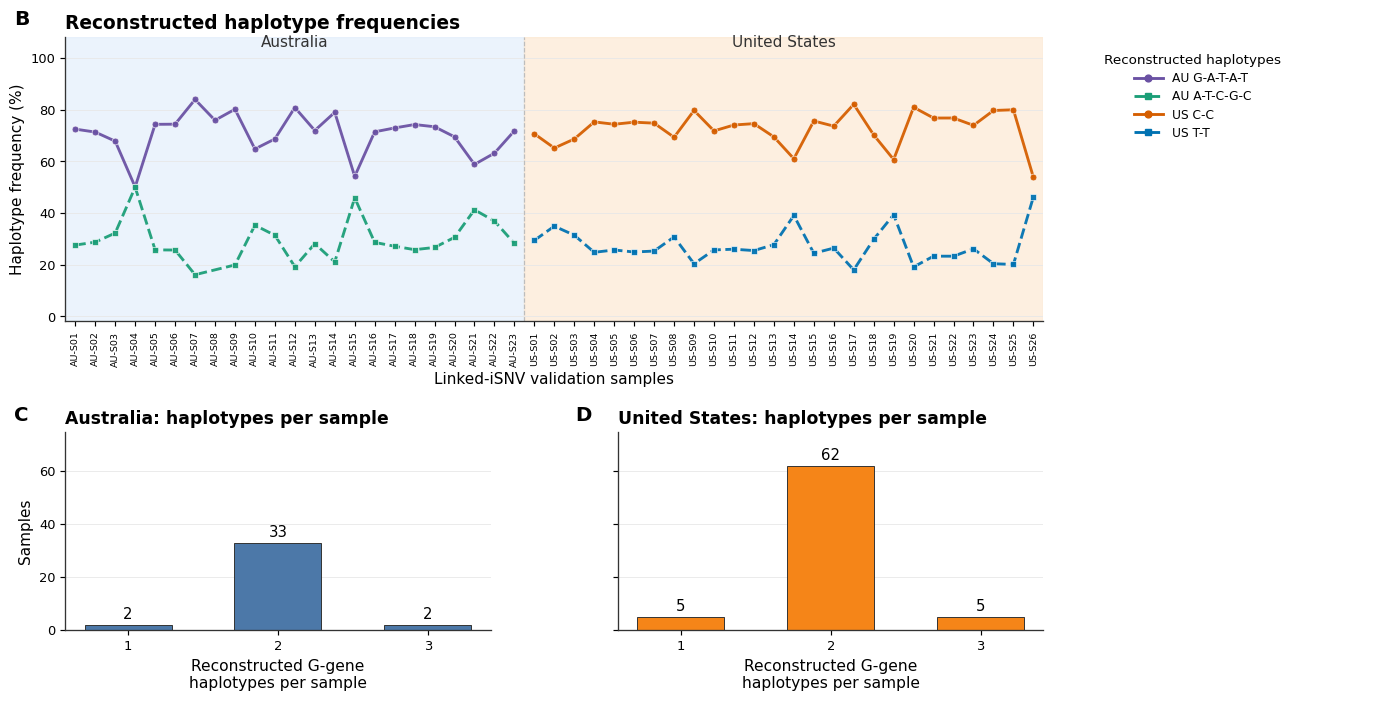

In [5]:
fig, paths = au.draw_haplotype_reconstruction(hap, count_values, FIG_DIR)
display(paths)
plt.show()
